# IMPORT

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.impute import KNNImputer
import os
import joblib
import warnings
import time

warnings.filterwarnings('ignore')


# EDA

In [85]:
# Load data
data = pd.read_csv('diabetes_frankurt_germany.csv')
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (2000, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [86]:
# Cek missing values dan nilai 0
print("Missing values:")
print(data.isnull().sum())

# Total baris yang memiliki missing values
total_baris_kosong = data.isnull().any(axis=1).sum()
print(f"\nTotal baris yang memiliki missing values: {total_baris_kosong}")
print(f"Persentase baris dengan missing values: {(total_baris_kosong/len(data)*100):.2f}%")

print("\nNilai 0 pada setiap kolom:")
jumlah_nol = {}
for kolom in data.columns:
    if kolom != 'Outcome':
        hitung_nol = (data[kolom] == 0).sum()
        jumlah_nol[kolom] = hitung_nol
        print(f"{kolom}: {hitung_nol}")

# Total baris yang memiliki minimal satu nilai 0 (selain Outcome)
fitur_dengan_nol = data.drop('Outcome', axis=1) == 0
total_baris_nol = fitur_dengan_nol.any(axis=1).sum()
print(f"\nTotal baris yang memiliki minimal satu nilai 0: {total_baris_nol}")
print(f"Persentase baris dengan nilai 0: {(total_baris_nol/len(data)*100):.2f}%")

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total baris yang memiliki missing values: 0
Persentase baris dengan missing values: 0.00%

Nilai 0 pada setiap kolom:
Pregnancies: 301
Glucose: 13
BloodPressure: 90
SkinThickness: 573
Insulin: 956
BMI: 28
DiabetesPedigreeFunction: 0
Age: 0

Total baris yang memiliki minimal satu nilai 0: 1124
Persentase baris dengan nilai 0: 56.20%


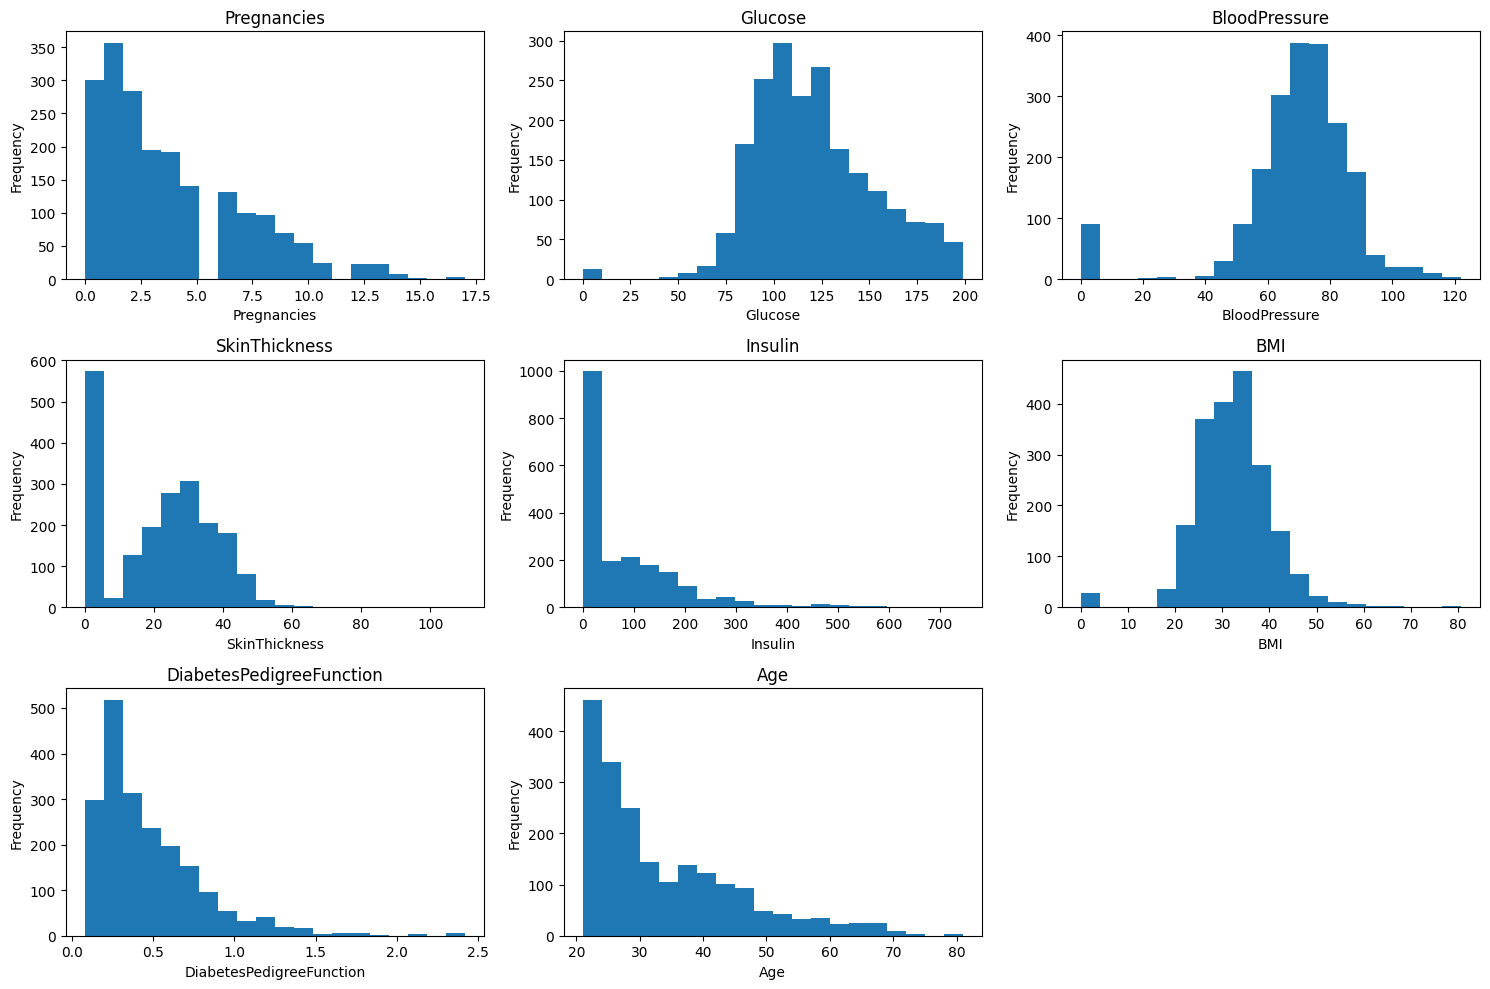

In [87]:
# Distribusi setiap fitur
plt.figure(figsize=(15, 10))
for i, kolom in enumerate(data.columns):
    if kolom == 'Outcome':
        continue
    plt.subplot(3, 3, i+1)
    plt.hist(data[kolom], bins=20)
    plt.title(kolom)
    plt.xlabel(kolom)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

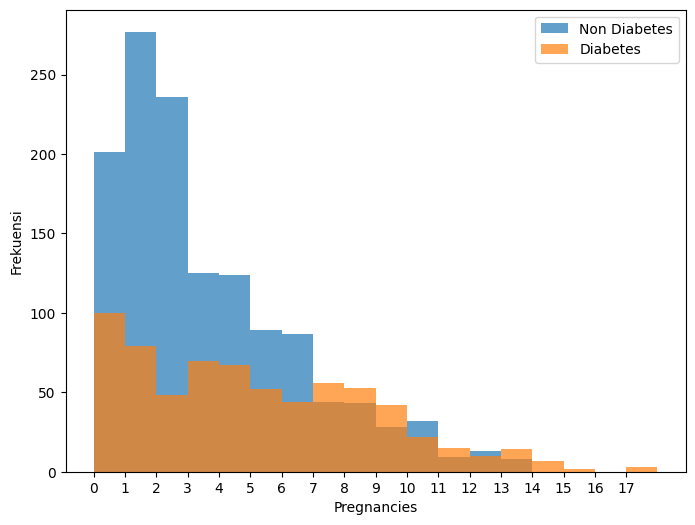

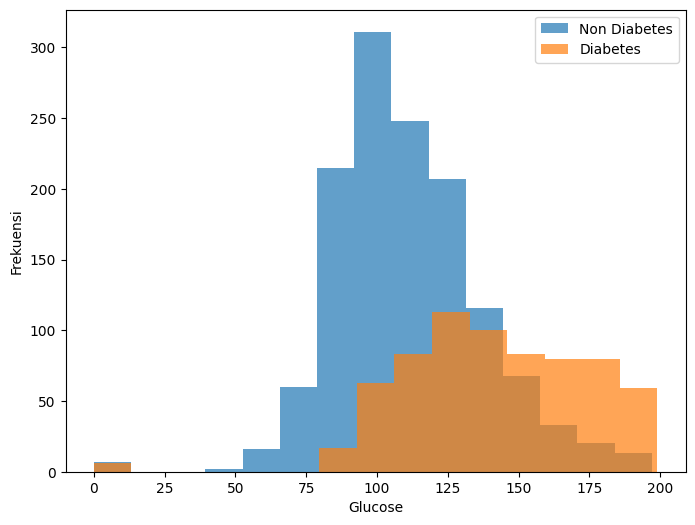

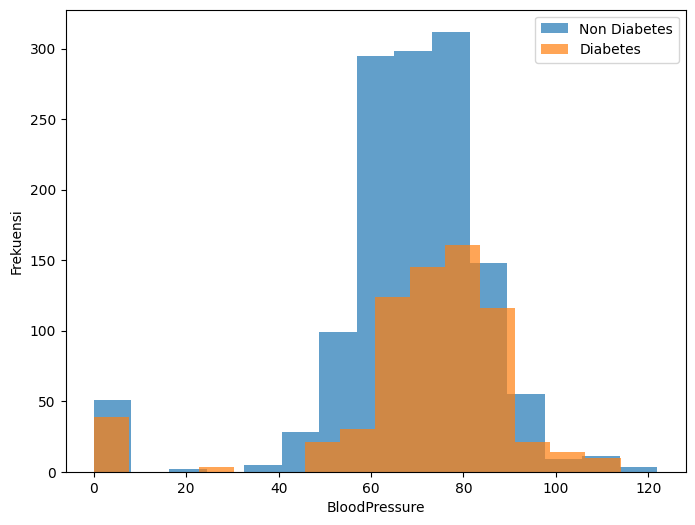

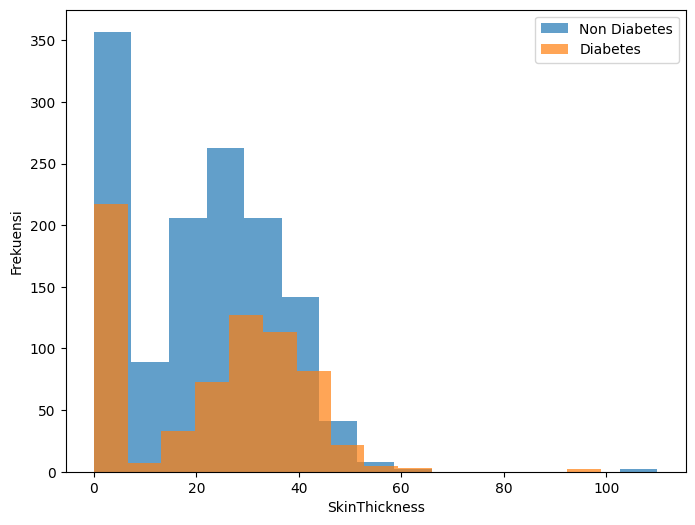

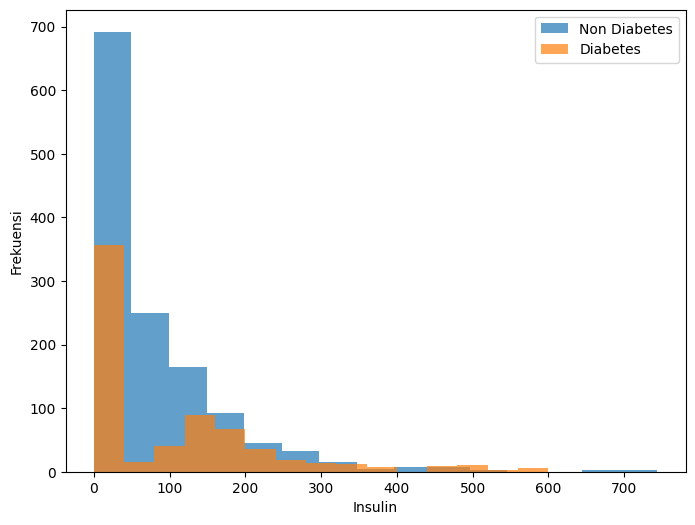

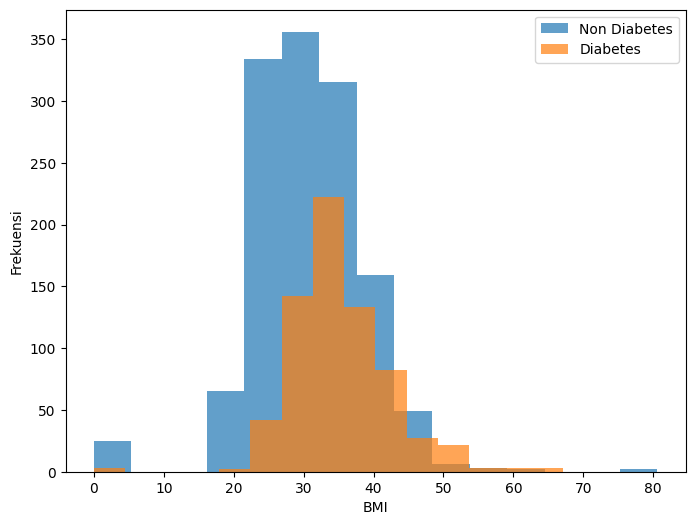

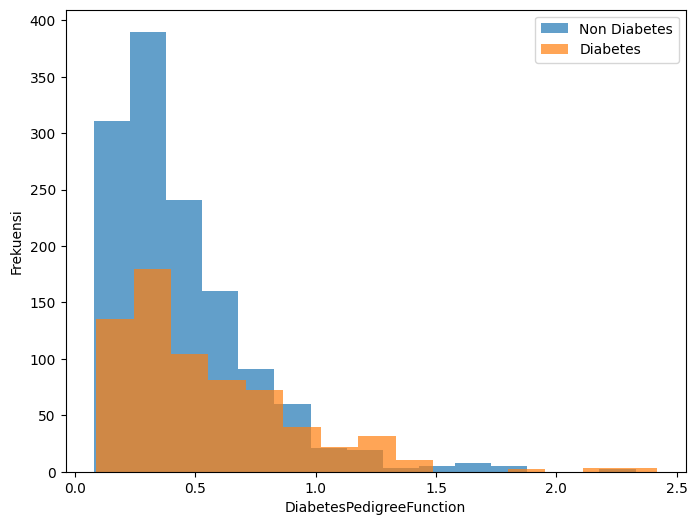

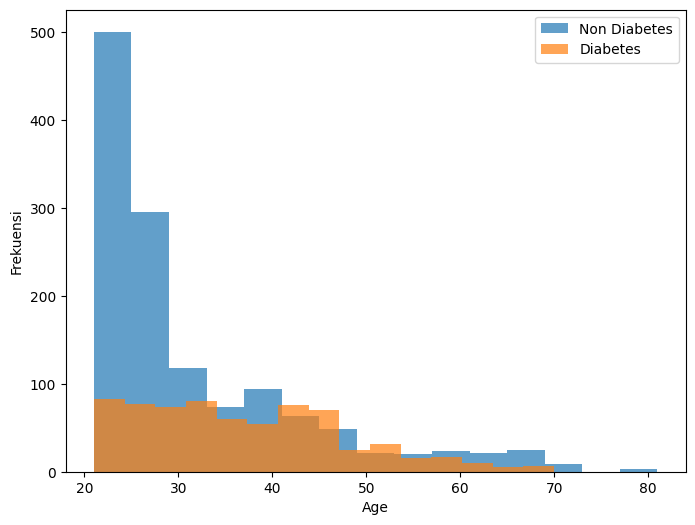

In [88]:
# Distribusi fitur terhadap target (Outcome) - satu per satu
features = data.columns[:-1]  # semua kecuali Outcome

for kolom in features:
    plt.figure(figsize=(8, 6))
    for outcome in [0, 1]:
        isi_data = data[data['Outcome'] == outcome][kolom]
        label = 'Non Diabetes' if outcome == 0 else 'Diabetes'
        if kolom == "Pregnancies":
            bins = range(int(data[kolom].min()), int(data[kolom].max()) + 2)
        else :
            bins = 15
        plt.hist(isi_data, alpha=0.7, label=label, bins=bins)
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')
    plt.legend()
    if kolom == "Pregnancies":
        plt.xticks(range(int(data[kolom].min()), int(data[kolom].max()) + 1))
    plt.show()

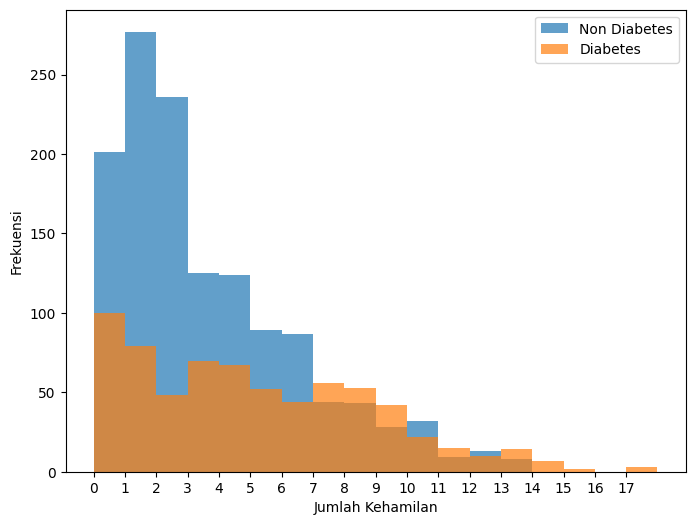

In [89]:
plt.figure(figsize=(8, 6))
for outcome in [0, 1]:
    isi_data = data[data['Outcome'] == outcome]['Pregnancies']
    label = 'Non Diabetes' if outcome == 0 else 'Diabetes'
    plt.hist(isi_data, alpha=0.7, label=label, bins=range(0, int(data['Pregnancies'].max()) + 2))
plt.xlabel('Jumlah Kehamilan')
plt.ylabel('Frekuensi')
plt.xticks(range(0, int(data['Pregnancies'].max()) + 1))
plt.legend()
plt.show()

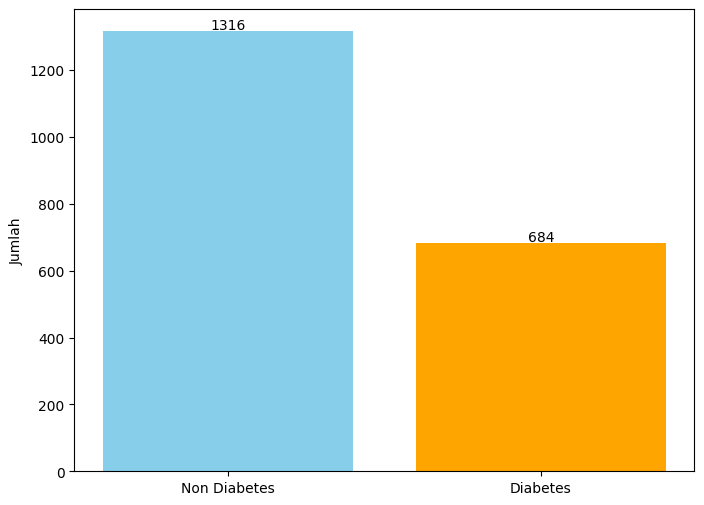

In [90]:
# Distribusi kelas pada target (Outcome)
plt.figure(figsize=(8, 6))
jumlah_outcome = data['Outcome'].value_counts()
plt.bar(jumlah_outcome.index, jumlah_outcome.values, color=['skyblue', 'orange'])
plt.ylabel('Jumlah')
plt.xticks([0, 1], ['Non Diabetes', 'Diabetes'])  # Menambahkan baris ini
for i, v in enumerate(jumlah_outcome.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

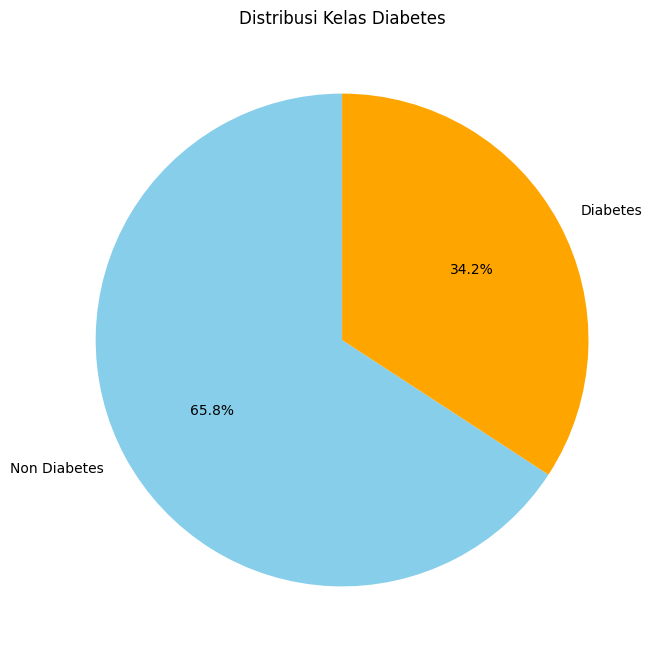

In [91]:
# Pie chart distribusi kelas
plt.figure(figsize=(8, 8))
jumlah_outcome = data['Outcome'].value_counts()
labels = ['Non Diabetes', 'Diabetes']
colors = ['skyblue', 'orange']
plt.pie(jumlah_outcome.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribusi Kelas Diabetes')
plt.show()

# PREPOCESSING

## IMPUTASI - KNN

In [92]:
kolom_imputasi = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data_inputasi = data.copy()

In [93]:
for kolom in kolom_imputasi:
    hitung_nol = (data_inputasi[kolom] == 0).sum()
    print(f"{kolom}: {hitung_nol}")
for kolom in kolom_imputasi:
    data_inputasi.loc[data_inputasi[kolom] == 0, kolom] = np.nan
data_inputasi.head()

Glucose: 13
BloodPressure: 90
SkinThickness: 573
Insulin: 956
BMI: 28


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138.0,62.0,35.0,NaN,33.6,0.127,47,1
1,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0
2,0,145.0,NaN,NaN,NaN,44.2,0.630,31,1
3,0,135.0,68.0,42.0,250.0,42.3,0.365,24,1
4,1,139.0,62.0,41.0,480.0,40.7,0.536,21,0


In [94]:
# Pisahkan fitur dan target
X_untuk_imputasi = data_inputasi.drop('Outcome', axis=1)
y_asli = data_inputasi['Outcome']

In [95]:
imputer_knn = KNNImputer(n_neighbors=5)

In [96]:
X_terimputasi = imputer_knn.fit_transform(X_untuk_imputasi)

In [97]:
data_akhir = pd.DataFrame(X_terimputasi, columns=X_untuk_imputasi.columns)
data_akhir['Outcome'] = y_asli.values

In [98]:
data_akhir = pd.DataFrame(X_terimputasi, columns=X_untuk_imputasi.columns)
data_akhir['Outcome'] = y_asli.values

In [99]:
for col in kolom_imputasi:
    zero_count = (data_akhir[col] == 0).sum()
    print(f"{col}: {zero_count}")

Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


In [100]:
data = data_akhir.copy()

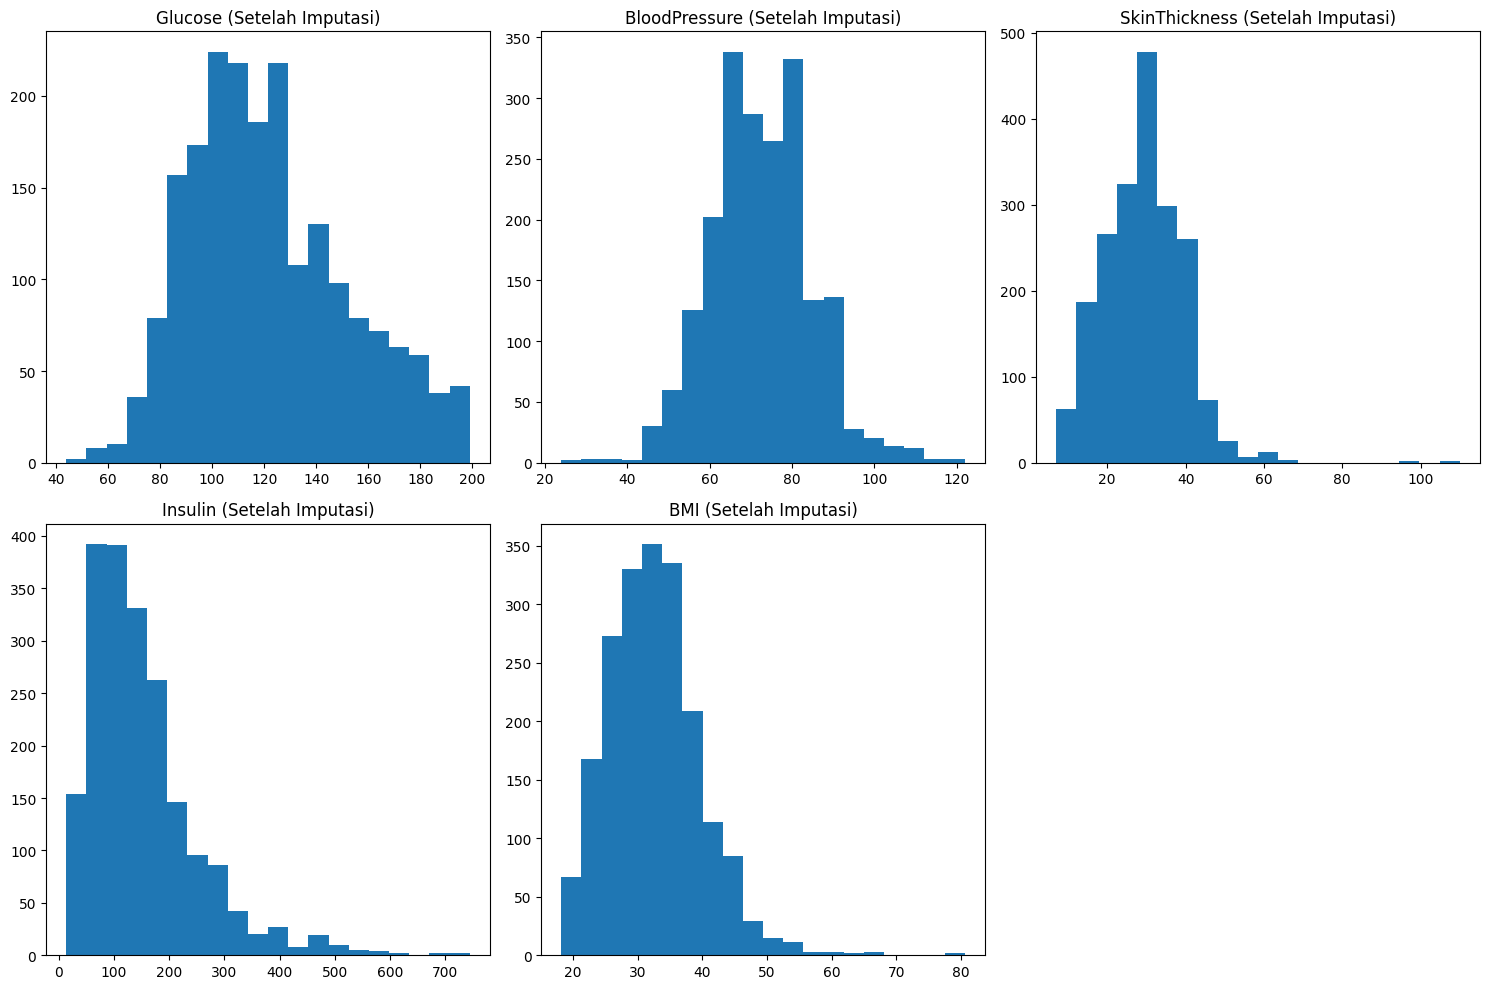

In [101]:
# Cek distribusi setelah imputasi
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.hist(data['Glucose'], bins=20)
plt.title('Glucose (Setelah Imputasi)')

plt.subplot(2, 3, 2)
plt.hist(data['BloodPressure'], bins=20)
plt.title('BloodPressure (Setelah Imputasi)')

plt.subplot(2, 3, 3)
plt.hist(data['SkinThickness'], bins=20)
plt.title('SkinThickness (Setelah Imputasi)')

plt.subplot(2, 3, 4)
plt.hist(data['Insulin'], bins=20)
plt.title('Insulin (Setelah Imputasi)')

plt.subplot(2, 3, 5)
plt.hist(data['BMI'], bins=20)
plt.title('BMI (Setelah Imputasi)')

plt.tight_layout()
plt.show()

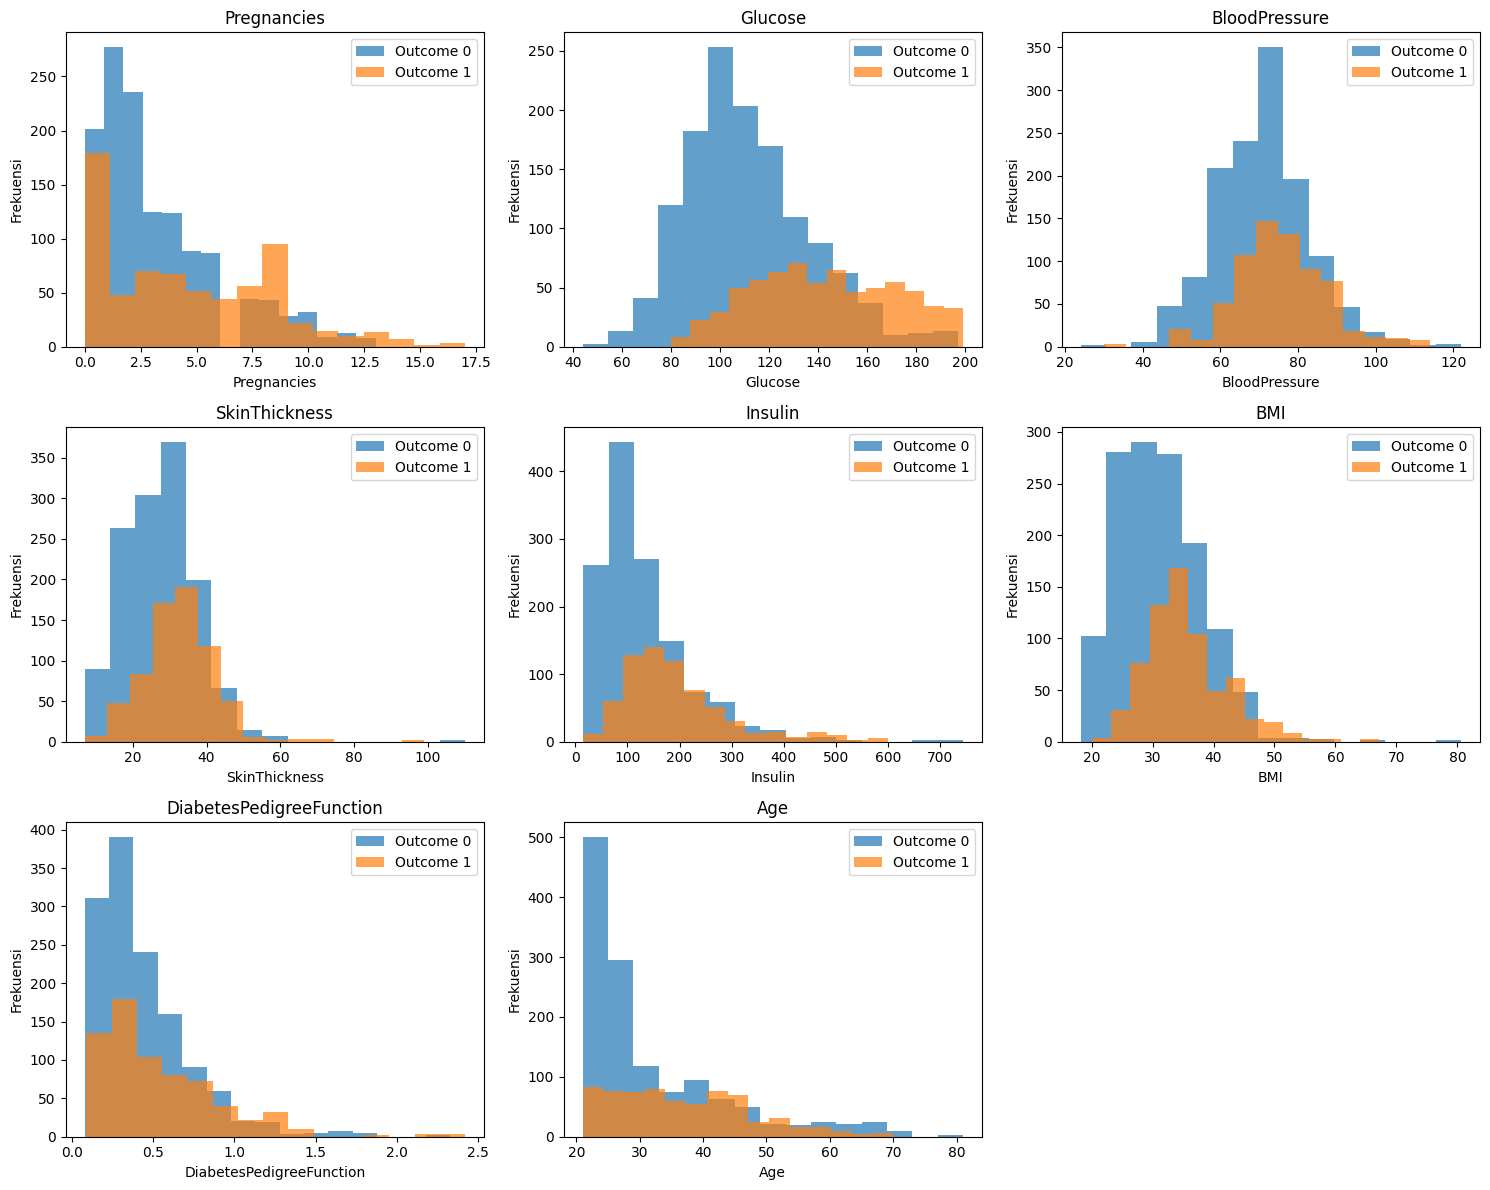

In [102]:
# Distribusi fitur terhadap target (Outcome)
fitur = data.columns[:-1]  # semua kecuali Outcome
plt.figure(figsize=(15, 12))
for i, kolom in enumerate(fitur):
    plt.subplot(3, 3, i+1)
    for outcome in [0, 1]:
        isi_data = data[data['Outcome'] == outcome][kolom]
        plt.hist(isi_data, alpha=0.7, label=f'Outcome {outcome}', bins=15)
    plt.title(kolom)
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')
    plt.legend()
plt.tight_layout()
plt.show()

In [103]:
# Pisah fitur dan target
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [104]:
X_latih, X_uji, y_latih, y_uji = train_test_split(
    X, y, test_size=0.3, random_state=42,
)

In [105]:
y_latih.value_counts(), y_uji.value_counts()

(Outcome
 0    927
 1    473
 Name: count, dtype: int64,
 Outcome
 0    389
 1    211
 Name: count, dtype: int64)

## NORMALISASI

In [106]:
skala = MinMaxScaler()
skala.fit(X_latih)
X_latih_dinormalisasi = skala.transform(X_latih)
X_uji_dinormalisasi = skala.transform(X_uji)
X_latih_dinormalisasi = pd.DataFrame(X_latih_dinormalisasi, columns=X.columns)
X_uji_dinormalisasi = pd.DataFrame(X_uji_dinormalisasi, columns=X.columns)

In [107]:
X_latih_dinormalisasi.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.352941,0.516129,0.489796,0.198039,0.138630,0.150641,0.123826,0.133333
1,0.058824,0.483871,0.204082,0.382353,0.067123,0.277244,0.086251,0.066667
2,0.470588,0.425806,0.530612,0.247059,0.242192,0.153846,0.067891,0.616667
3,0.000000,0.541935,0.448980,0.107843,0.227397,0.197115,0.560632,0.066667
4,0.000000,0.412903,0.448980,0.117647,0.112877,0.145833,0.302733,0.183333


## BALANCING DATA - SMOTE

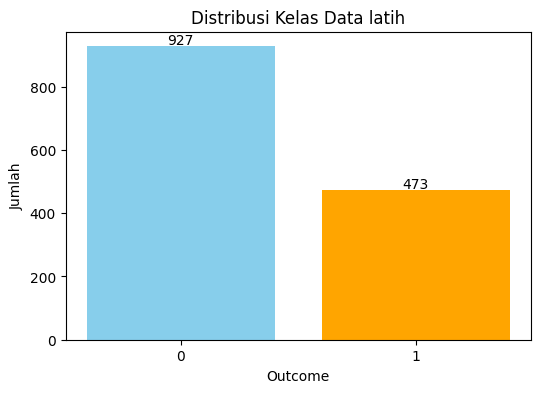

In [108]:
# Diagram distribusi kelas sebelum SMOTE
plt.figure(figsize=(6, 4))
plt.bar([0, 1], [(y_latih == 0).sum(), (y_latih == 1).sum()], color=['skyblue', 'orange'])
plt.title('Distribusi Kelas Data latih')
plt.xlabel('Outcome')
plt.ylabel('Jumlah')
plt.xticks([0, 1])
for i, v in enumerate([(y_latih == 0).sum(), (y_latih == 1).sum()]):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

In [109]:
smote = SMOTE(random_state=42)
X_latih_smote, y_latih_smote = smote.fit_resample(X_latih_dinormalisasi, y_latih)

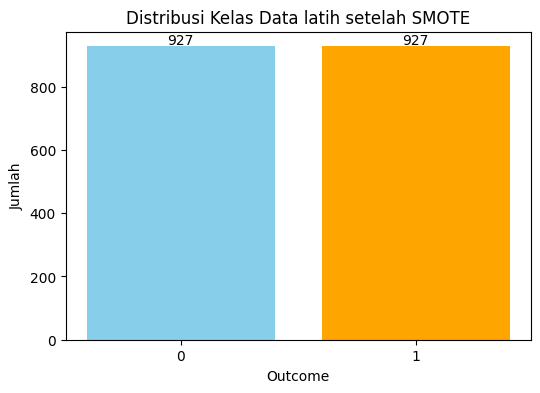

In [110]:
# Diagram distribusi kelas sebelum SMOTE
plt.figure(figsize=(6, 4))
plt.bar([0, 1], [(y_latih_smote == 0).sum(), (y_latih_smote == 1).sum()], color=['skyblue', 'orange'])
plt.title('Distribusi Kelas Data latih setelah SMOTE')
plt.xlabel('Outcome')
plt.ylabel('Jumlah')
plt.xticks([0, 1])
for i, v in enumerate([(y_latih_smote == 0).sum(), (y_latih_smote == 1).sum()]):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

# MODELLING

## HYPERPARAMETER TUNING

In [111]:
jumlah_fold = 5
kfold = KFold(n_splits=jumlah_fold, shuffle=True, random_state=42)
ukuran_fold = len(X_latih_smote) // jumlah_fold
sisa_fold = len(X_latih_smote) % jumlah_fold

print(f"\nUkuran per fold:")
total_validasi = 0
for i in range(jumlah_fold):
    if i < sisa_fold:
        ukuran = ukuran_fold + 1
    else:
        ukuran = ukuran_fold
    total_validasi += ukuran
    print(f"  Fold {i+1}: {ukuran} sampel")



print(" Detail setiap iterasi cross validation")
for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_latih_smote)):
    print(f"\nIterasi {fold_idx + 1}:")
    print(f"  Data Training: {len(train_idx):,} sampel")
    print(f"  Data Validasi: {len(val_idx):,} sampel")


Ukuran per fold:
  Fold 1: 371 sampel
  Fold 2: 371 sampel
  Fold 3: 371 sampel
  Fold 4: 371 sampel
  Fold 5: 370 sampel
 Detail setiap iterasi cross validation

Iterasi 1:
  Data Training: 1,483 sampel
  Data Validasi: 371 sampel

Iterasi 2:
  Data Training: 1,483 sampel
  Data Validasi: 371 sampel

Iterasi 3:
  Data Training: 1,483 sampel
  Data Validasi: 371 sampel

Iterasi 4:
  Data Training: 1,483 sampel
  Data Validasi: 371 sampel

Iterasi 5:
  Data Training: 1,484 sampel
  Data Validasi: 370 sampel


In [112]:
# list parameter model
# Define parameter grids untuk setiap model
param_grids = {
    'SVM': {
        'C': [0.1, 1, 10, 100, 1000],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    },
    'KNN': {
        'n_neighbors': [5, 7, 9, 11, 13, 15, 17, 19],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'MLP': {
        'max_iter': [100, 500, 1000],
        'hidden_layer_sizes':[(100,), (50,50), (30,20), (20,10)],
        'activation': ['relu', 'tanh', 'logistic'],
        'alpha': [0.0001, 0.001, 0.01, 0.1],
    },
    'LogReg': {
        'C': np.logspace(-4, 4, 20),
        'solver': ['liblinear', 'lbfgs'],
        'penalty': ['l1','l2']
    },
}

### LOGISTIC

In [113]:
waktu_mulai_tuning = time.time()

model_lr = LogisticRegression(random_state=42)
grid_search_lr = GridSearchCV(model_lr, param_grids['LogReg'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_lr.fit(X_latih_smote, y_latih_smote)

waktu_tuning = (time.time() - waktu_mulai_tuning) * 1000
print(f"Waktu tuning: {waktu_tuning:.2f} ms")
print(f"LR Best Score: {grid_search_lr.best_score_:.4f}")
print(f"LR Best Params: {grid_search_lr.best_params_}")

# menampilkan hasil per fold terbaik
results_lr = pd.DataFrame(grid_search_lr.cv_results_)
best_idx = grid_search_lr.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_lr.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_lr.best_score_:.4f}")
print(f"Std: {results_lr.loc[best_idx, 'std_test_score']:.4f}")


# Waktu Training dengan parameter terbaik
print("\nTraining model dengan parameter terbaik")
waktu_mulai_training = time.time()
lr_final = grid_search_lr.best_estimator_
lr_final.fit(X_latih_smote, y_latih_smote)
waktu_training = (time.time() - waktu_mulai_training) * 1000
print(f" Waktu training dengan parameter terbaik: {waktu_training:.2f} ms")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Waktu tuning: 7422.88 ms
LR Best Score: 0.7481
LR Best Params: {'C': np.float64(0.012742749857031334), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.7601
Fold 2: 0.7089
Fold 3: 0.7466
Fold 4: 0.7655
Fold 5: 0.7595
Mean: 0.7481
Std: 0.0206

Training model dengan parameter terbaik
 Waktu training dengan parameter terbaik: 3.16 ms


### KNN

In [114]:


waktu_mulai_tuning = time.time()
model_knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(model_knn, param_grids['KNN'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_knn.fit(X_latih_smote, y_latih_smote)
waktu_tuning = (time.time() - waktu_mulai_tuning) * 1000
print(f"Waktu tuning: {waktu_tuning:.2f} ms")
print(f"KNN Best Score: {grid_search_knn.best_score_:.4f}")
print(f"KNN Best Params: {grid_search_knn.best_params_}")

# menampilkan hasil per fold terbaik
results_knn = pd.DataFrame(grid_search_knn.cv_results_)
best_idx = grid_search_knn.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_knn.best_score_:.4f}")
print(f"Std: {results_knn.loc[best_idx, 'std_test_score']:.4f}")

# waktu Training dengan parameter terbaik
print("\nTraining model dengan parameter terbaik")
waktu_mulai_training = time.time()
knn_final = grid_search_knn.best_estimator_
knn_final.fit(X_latih_smote, y_latih_smote)
waktu_training = (time.time() - waktu_mulai_training) * 1000
print(f"Waktu training dengan parameter terbaik: {waktu_training:.2f} ms")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Waktu tuning: 643.31 ms
KNN Best Score: 0.9445
KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Fold 1: 0.9461
Fold 2: 0.9380
Fold 3: 0.9326
Fold 4: 0.9434
Fold 5: 0.9622
Mean: 0.9445
Std: 0.0100

Training model dengan parameter terbaik
Waktu training dengan parameter terbaik: 3.65 ms


### SVM

In [115]:
waktu_mulai_tuning = time.time()

model_svm = SVC(random_state=42, probability=True)
grid_search_svm = GridSearchCV(model_svm, param_grids['SVM'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm.fit(X_latih_smote, y_latih_smote)

waktu_tuning = (time.time() - waktu_mulai_tuning) * 1000
print(f"Waktu tuning: {waktu_tuning:.2f} ms")
print(f"SVM Best Score: {grid_search_svm.best_score_:.4f}")
print(f"SVM Best Params: {grid_search_svm.best_params_}")


# menampilkan hasil per fold terbaik
results_svm = pd.DataFrame(grid_search_svm.cv_results_)
best_idx = grid_search_svm.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_svm.best_score_:.4f}")
print(f"Std: {results_svm.loc[best_idx, 'std_test_score']:.4f}")


# Waktu Training dengan parameter terbaik
print("\nTraining model dengan parameter terbaik")
waktu_mulai_training = time.time()
svm_final = grid_search_svm.best_estimator_
svm_final.fit(X_latih_smote, y_latih_smote)
waktu_training = (time.time() - waktu_mulai_training) * 1000
print(f"Waktu training dengan parameter terbaik: {waktu_training:.2f} ms")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Waktu tuning: 10704.55 ms
SVM Best Score: 0.9180
SVM Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.9326
Fold 2: 0.9218
Fold 3: 0.9057
Fold 4: 0.9030
Fold 5: 0.9270
Mean: 0.9180
Std: 0.0117

Training model dengan parameter terbaik
Waktu training dengan parameter terbaik: 2426.74 ms


### MLP

In [116]:
waktu_mulai_tuning = time.time()

model_mlp = MLPClassifier(random_state=42)
grid_search_mlp = GridSearchCV(model_mlp,param_grids['MLP'] , cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_mlp.fit(X_latih_smote, y_latih_smote)

waktu_tuning = (time.time() - waktu_mulai_tuning) * 1000
print(f"Waktu tuning: {waktu_tuning:.2f} ms")

print(f"MLP Best Score: {grid_search_mlp.best_score_:.4f}")
print(f"MLP Best Params: {grid_search_mlp.best_params_}")

# menampilkan hasil per fold terbaik
results_mlp = pd.DataFrame(grid_search_mlp.cv_results_)
best_idx = grid_search_mlp.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_mlp.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_mlp.best_score_:.4f}")
print(f"Std: {results_mlp.loc[best_idx, 'std_test_score']:.4f}")


# Waktu Training dengan parameter terbaik
print("\nTraining model dengan parameter terbaik")
waktu_mulai_training = time.time()
mlp_final = grid_search_mlp.best_estimator_
mlp_final.fit(X_latih_smote, y_latih_smote)
waktu_training = (time.time() - waktu_mulai_training) * 1000
print(f"Waktu training dengan parameter terbaik: {waktu_training:.2f} ms")

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Waktu tuning: 186258.20 ms
MLP Best Score: 0.8290
MLP Best Params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (50, 50), 'max_iter': 1000}
Fold 1: 0.8113
Fold 2: 0.8329
Fold 3: 0.8329
Fold 4: 0.8194
Fold 5: 0.8486
Mean: 0.8290
Std: 0.0128

Training model dengan parameter terbaik
Waktu training dengan parameter terbaik: 2558.47 ms


In [117]:
lr_final = grid_search_lr.best_estimator_
knn_final = grid_search_knn.best_estimator_
svm_final = grid_search_svm.best_estimator_
mlp_final = grid_search_mlp.best_estimator_

## MEMBUAT FITUR DARI PREDIKSI MODEL DASAR - DATA TRAINING

In [118]:
prediksi_lr = cross_val_predict(lr_final, X_latih_smote, y_latih_smote, cv=kfold, method='predict_proba')
prediksi_knn = cross_val_predict(knn_final, X_latih_smote, y_latih_smote, cv=kfold, method='predict_proba')
prediksi_svm = cross_val_predict(svm_final, X_latih_smote, y_latih_smote, cv=kfold, method='predict_proba')
prediksi_mlp = cross_val_predict(mlp_final, X_latih_smote, y_latih_smote, cv=kfold, method='predict_proba')


fitur_meta = np.column_stack([prediksi_lr, prediksi_knn, prediksi_svm, prediksi_mlp])
df_fitur_meta = pd.DataFrame(fitur_meta, columns=[
    'lr_prob_0', 'lr_prob_1',      # LR probabilitas kelas 0 dan 1
    'knn_prob_0', 'knn_prob_1',    # KNN probabilitas kelas 0 dan 1
    'svm_prob_0', 'svm_prob_1',    # SVM probabilitas kelas 0 dan 1
    'mlp_prob_0', 'mlp_prob_1'     # MLP probabilitas kelas 0 dan 1
])

print(f"Bentuk fitur meta: {fitur_meta.shape}")
print(df_fitur_meta.head())

Bentuk fitur meta: (1854, 8)
   lr_prob_0  lr_prob_1  knn_prob_0  knn_prob_1  svm_prob_0  svm_prob_1  \
0   0.485198   0.514802    0.000000    1.000000    0.259941    0.740059   
1   0.504574   0.495426    1.000000    0.000000    0.680093    0.319907   
2   0.447929   0.552071    1.000000    0.000000    0.992671    0.007329   
3   0.498156   0.501844    0.000000    1.000000    0.260200    0.739800   
4   0.520874   0.479126    0.603806    0.396194    0.575927    0.424073   

   mlp_prob_0  mlp_prob_1  
0    0.236136    0.763864  
1    0.785630    0.214370  
2    0.974301    0.025699  
3    0.829826    0.170174  
4    0.588404    0.411596  


### MEMBUAT FITUR META DATA TESTING

In [119]:
# training base model dengan seluruh data training untuk prediksi pada data test

lr_final.fit(X_latih_smote, y_latih_smote)
knn_final.fit(X_latih_smote, y_latih_smote)
svm_final.fit(X_latih_smote, y_latih_smote)
mlp_final.fit(X_latih_smote, y_latih_smote)

# membuat meta features untuk data test
prediksi_uji_lr = lr_final.predict_proba(X_uji_dinormalisasi)
prediksi_uji_knn = knn_final.predict_proba(X_uji_dinormalisasi)
prediksi_uji_svm = svm_final.predict_proba(X_uji_dinormalisasi)
prediksi_uji_mlp = mlp_final.predict_proba(X_uji_dinormalisasi)

fitur_meta_uji = np.column_stack([prediksi_uji_lr, prediksi_uji_knn, prediksi_uji_svm, prediksi_uji_mlp])
df_fitur_meta_uji = pd.DataFrame(fitur_meta_uji, columns=[
    'lr_prob_0', 'lr_prob_1',      # LR probabilitas kelas 0 dan 1
    'knn_prob_0', 'knn_prob_1',    # KNN probabilitas kelas 0 dan 1
    'svm_prob_0', 'svm_prob_1',    # SVM probabilitas kelas 0 dan 1
    'mlp_prob_0', 'mlp_prob_1'     # MLP probabilitas kelas 0 dan 1
])

print(f"Test Meta-features shape: {df_fitur_meta_uji.shape}")
print(df_fitur_meta_uji.head())

# definisikan inputan untuk meta learner
X_meta_latih = df_fitur_meta
y_meta_latih = y_latih_smote

X_meta_uji = df_fitur_meta_uji
y_meta_uji = y_uji
print(f"X_meta_latih: {X_meta_latih.shape}")
print(f"y_meta_latih: {y_meta_latih.shape}")
print(f"X_meta_uji: {X_meta_uji.shape}")
print(f"y_meta_uji: {y_meta_uji.shape}")

Test Meta-features shape: (600, 8)
   lr_prob_0  lr_prob_1  knn_prob_0  knn_prob_1    svm_prob_0  svm_prob_1  \
0   0.442662   0.557338         0.0         1.0  1.928176e-01    0.807182   
1   0.559363   0.440637         1.0         0.0  9.919510e-01    0.008049   
2   0.400757   0.599243         0.0         1.0  9.600449e-02    0.903996   
3   0.478778   0.521222         0.0         1.0  1.929699e-01    0.807030   
4   0.458693   0.541307         0.0         1.0  9.151205e-14    1.000000   

   mlp_prob_0  mlp_prob_1  
0    0.568190    0.431810  
1    0.999434    0.000566  
2    0.230677    0.769323  
3    0.315904    0.684096  
4    0.012237    0.987763  
X_meta_latih: (1854, 8)
y_meta_latih: (1854,)
X_meta_uji: (600, 8)
y_meta_uji: (600,)


### SKENARIO 1: META-LEARNER KNN

In [120]:
print("\n" + "="*60)
print("SKENARIO 1: META-LEARNER KNN")
print("="*60)

waktu_mulai_tuning = time.time()

knn_meta = KNeighborsClassifier()
grid_search_knn_meta = GridSearchCV(knn_meta, param_grids['KNN'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_knn_meta.fit(X_meta_latih, y_meta_latih)

waktu_tuning = (time.time() - waktu_mulai_tuning) * 1000
print(f"Waktu tuning: {waktu_tuning:.2f} ms")

print(f"KNN Meta Best Score: {grid_search_knn_meta.best_score_:.4f}")
print(f"KNN Meta Best Params: {grid_search_knn_meta.best_params_}")

# Menampilkan hasil per fold terbaik
results_knn_meta = pd.DataFrame(grid_search_knn_meta.cv_results_)
best_idx = grid_search_knn_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn_meta.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_knn_meta.best_score_:.4f}")
print(f"Std: {results_knn_meta.loc[best_idx, 'std_test_score']:.4f}")

# Waktu Training dengan parameter terbaik
print("\nTraining model dengan parameter terbaik")
waktu_mulai_training = time.time()
knn_meta_final = grid_search_knn_meta.best_estimator_
knn_meta_final.fit(X_meta_latih, y_meta_latih)
waktu_training = (time.time() - waktu_mulai_training) * 1000
print(f"Waktu training dengan parameter terbaik: {waktu_training:.2f} ms")

# Train final model dan prediksi
knn_meta_final = grid_search_knn_meta.best_estimator_
pred_knn_meta = knn_meta_final.predict(X_meta_uji)


SKENARIO 1: META-LEARNER KNN
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Waktu tuning: 350.59 ms
KNN Meta Best Score: 0.9455
KNN Meta Best Params: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'uniform'}
Fold 1: 0.9542
Fold 2: 0.9488
Fold 3: 0.9326
Fold 4: 0.9326
Fold 5: 0.9595
Mean: 0.9455
Std: 0.0111

Training model dengan parameter terbaik
Waktu training dengan parameter terbaik: 2.03 ms


### SKENARIO 2: META-LEARNER SVM

In [121]:
### SKENARIO 2: META-LEARNER SVM
print("\n" + "="*60)
print("SKENARIO 2: META-LEARNER SVM")
print("="*60)

waktu_mulai_tuning = time.time()

svm_meta = SVC(random_state=42, probability=True)
grid_search_svm_meta = GridSearchCV(svm_meta, param_grids['SVM'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_svm_meta.fit(X_meta_latih, y_meta_latih)

waktu_tuning = (time.time() - waktu_mulai_tuning) * 1000
print(f"Waktu tuning: {waktu_tuning:.2f} ms")

print(f"SVM Meta Best Score: {grid_search_svm_meta.best_score_:.4f}")
print(f"SVM Meta Best Params: {grid_search_svm_meta.best_params_}")

# Menampilkan hasil per fold terbaik
results_svm_meta = pd.DataFrame(grid_search_svm_meta.cv_results_)
best_idx = grid_search_svm_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm_meta.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_svm_meta.best_score_:.4f}")
print(f"Std: {results_svm_meta.loc[best_idx, 'std_test_score']:.4f}")


# Waktu Training dengan parameter terbaik
print("\nTraining model dengan parameter terbaik")
waktu_mulai_training = time.time()
svm_meta_final = grid_search_svm_meta.best_estimator_
svm_meta_final.fit(X_meta_latih, y_meta_latih)
waktu_training = (time.time() - waktu_mulai_training) * 1000
print(f"Waktu training dengan parameter terbaik: {waktu_training:.2f} ms")

# Train final model dan prediksi
svm_meta_final = grid_search_svm_meta.best_estimator_
pred_svm_meta = svm_meta_final.predict(X_meta_uji)


SKENARIO 2: META-LEARNER SVM
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Waktu tuning: 4338.00 ms
SVM Meta Best Score: 0.9450
SVM Meta Best Params: {'C': 1000, 'gamma': 'scale', 'kernel': 'linear'}
Fold 1: 0.9515
Fold 2: 0.9434
Fold 3: 0.9353
Fold 4: 0.9380
Fold 5: 0.9568
Mean: 0.9450
Std: 0.0081

Training model dengan parameter terbaik
Waktu training dengan parameter terbaik: 835.89 ms


### SKENARIO 3: META-LEARNER MLP

In [122]:
### SKENARIO 3: META-LEARNER MLP
print("\n" + "="*60)
print("SKENARIO 3: META-LEARNER MLP")
print("="*60)

waktu_mulai_tuning = time.time()


mlp_meta = MLPClassifier(random_state=42)
grid_search_mlp_meta = GridSearchCV(mlp_meta, param_grids['MLP'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_mlp_meta.fit(X_meta_latih, y_meta_latih)

waktu_tuning = (time.time() - waktu_mulai_tuning) * 1000
print(f"Waktu tuning: {waktu_tuning:.2f} ms")

print(f"MLP Meta Best Score: {grid_search_mlp_meta.best_score_:.4f}")
print(f"MLP Meta Best Params: {grid_search_mlp_meta.best_params_}")

# Menampilkan hasil per fold terbaik
results_mlp_meta = pd.DataFrame(grid_search_mlp_meta.cv_results_)
best_idx = grid_search_mlp_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_mlp_meta.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_mlp_meta.best_score_:.4f}")
print(f"Std: {results_mlp_meta.loc[best_idx, 'std_test_score']:.4f}")

# Waktu Training dengan parameter terbaik
print("\nTraining model dengan parameter terbaik")
waktu_mulai_training = time.time()
mlp_meta_final = grid_search_mlp_meta.best_estimator_
mlp_meta_final.fit(X_meta_latih, y_meta_latih)
waktu_training = (time.time() - waktu_mulai_training) * 1000
print(f"Waktu training dengan parameter terbaik: {waktu_training:.2f} ms")

# Train final model dan prediksi
mlp_meta_final = grid_search_mlp_meta.best_estimator_
pred_mlp_meta = mlp_meta_final.predict(X_meta_uji)


SKENARIO 3: META-LEARNER MLP
Fitting 5 folds for each of 144 candidates, totalling 720 fits
Waktu tuning: 94205.87 ms
MLP Meta Best Score: 0.9472
MLP Meta Best Params: {'activation': 'logistic', 'alpha': 0.01, 'hidden_layer_sizes': (20, 10), 'max_iter': 500}
Fold 1: 0.9596
Fold 2: 0.9434
Fold 3: 0.9407
Fold 4: 0.9272
Fold 5: 0.9649
Mean: 0.9472
Std: 0.0136

Training model dengan parameter terbaik
Waktu training dengan parameter terbaik: 607.42 ms


### SKENARIO 4: META-LEARNER LOGISTIC REGRESSION

In [123]:
### SKENARIO 4: META-LEARNER LOGISTIC REGRESSION
print("\n" + "="*60)
print("SKENARIO 4: META-LEARNER LOGISTIC REGRESSION")
print("="*60)

waktu_mulai_tuning = time.time()

logreg_meta = LogisticRegression(random_state=42)
grid_search_logreg_meta = GridSearchCV(logreg_meta, param_grids['LogReg'], cv=kfold, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_logreg_meta.fit(X_meta_latih, y_meta_latih)

waktu_tuning = (time.time() - waktu_mulai_tuning) * 1000
print(f"Waktu tuning: {waktu_tuning:.2f} ms")

print(f"LogReg Meta Best Score: {grid_search_logreg_meta.best_score_:.4f}")
print(f"LogReg Meta Best Params: {grid_search_logreg_meta.best_params_}")

# Menampilkan hasil per fold terbaik
results_logreg_meta = pd.DataFrame(grid_search_logreg_meta.cv_results_)
best_idx = grid_search_logreg_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_logreg_meta.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_search_logreg_meta.best_score_:.4f}")
print(f"Std: {results_logreg_meta.loc[best_idx, 'std_test_score']:.4f}")

# Waktu Training dengan parameter terbaik
print("\nTraining model dengan parameter terbaik")
waktu_mulai_training = time.time()
logreg_meta_final = grid_search_logreg_meta.best_estimator_
logreg_meta_final.fit(X_meta_latih, y_meta_latih)
waktu_training = (time.time() - waktu_mulai_training) * 1000
print(f"Waktu training dengan parameter terbaik: {waktu_training:.2f} ms")

# Train final model dan prediksi
logreg_meta_final = grid_search_logreg_meta.best_estimator_
pred_logreg_meta = logreg_meta_final.predict(X_meta_uji)


SKENARIO 4: META-LEARNER LOGISTIC REGRESSION
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Waktu tuning: 409.78 ms
LogReg Meta Best Score: 0.9439
LogReg Meta Best Params: {'C': np.float64(0.615848211066026), 'penalty': 'l1', 'solver': 'liblinear'}
Fold 1: 0.9542
Fold 2: 0.9380
Fold 3: 0.9380
Fold 4: 0.9326
Fold 5: 0.9568
Mean: 0.9439
Std: 0.0097

Training model dengan parameter terbaik
Waktu training dengan parameter terbaik: 4.02 ms


# EVALUASI DAN PERBANDINGAN PERFORMANCE

In [124]:
# Evaluasi base models pada test set
print("\n" + "="*80)
print("PERBANDINGAN PERFORMANCE: BASE MODELS VS STACKING")
print("="*80)

# Prediksi base models pada test set
pred_model_dasar = {
    'LogReg': lr_final.predict(X_uji_dinormalisasi),
    'KNN': knn_final.predict(X_uji_dinormalisasi),
    'SVM': svm_final.predict(X_uji_dinormalisasi),
    'MLP': mlp_final.predict(X_uji_dinormalisasi)
}

# Function untuk menghitung metrics
def hitung_metrik(y_asli, y_prediksi, nama_model):
    akurasi = accuracy_score(y_asli, y_prediksi)
    presisi = precision_score(y_asli, y_prediksi)
    recall = recall_score(y_asli, y_prediksi)
    f1 = f1_score(y_asli, y_prediksi)

    return {
        'Model': nama_model,
        'Akurasi': akurasi,
        'Presisi': presisi,
        'Recall': recall,
        'Skor-F1': f1
    }

# Collect all results
hasil_perbandingan = []

# Base models
print("\nPERFORMA MODEL DASAR")
print("-" * 50)
for nama_model, prediksi in pred_model_dasar.items():
    metrics = hitung_metrik(y_uji, prediksi, nama_model)
    hasil_perbandingan.append(metrics)
    print(f"{nama_model}:")
    print(f"  Akurasi:  {metrics['Akurasi']:.4f}")
    print(f"  Presisi: {metrics['Presisi']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  Skor-F1:  {metrics['Skor-F1']:.4f}")
    print()

# Stacking models
print("PERFORMA MODEL STACKING:")
print("-" * 50)

stacking_predictions = {
    'Stacking_KNN': pred_knn_meta,
    'Stacking_SVM': pred_svm_meta,
    'Stacking_MLP': pred_mlp_meta,
    'Stacking_LogReg': pred_logreg_meta,

}


for nama_model, prediksi in stacking_predictions.items():
    metrics = hitung_metrik(y_uji, prediksi, nama_model)
    hasil_perbandingan.append(metrics)
    print(f"{nama_model}:")
    print(f"  Akurasi:  {metrics['Akurasi']:.4f}")
    print(f"  Presisi: {metrics['Presisi']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  Skor-F1:  {metrics['Skor-F1']:.4f}")
    print()

# PERBANDINGAN
df_perbandingan = pd.DataFrame(hasil_perbandingan)
print("\nRINGKASAN PERBANDINGAN:")
print("="*80)
print(df_perbandingan.round(4))


PERBANDINGAN PERFORMANCE: BASE MODELS VS STACKING

PERFORMA MODEL DASAR
--------------------------------------------------
LogReg:
  Akurasi:  0.7200
  Presisi: 0.5616
  Recall:    0.9289
  Skor-F1:  0.7000

KNN:
  Akurasi:  0.9433
  Presisi: 0.9005
  Recall:    0.9431
  Skor-F1:  0.9213

SVM:
  Akurasi:  0.9050
  Presisi: 0.8407
  Recall:    0.9005
  Skor-F1:  0.8696

MLP:
  Akurasi:  0.7950
  Presisi: 0.6538
  Recall:    0.8863
  Skor-F1:  0.7525

PERFORMA MODEL STACKING:
--------------------------------------------------
Stacking_KNN:
  Akurasi:  0.9567
  Presisi: 0.9263
  Recall:    0.9526
  Skor-F1:  0.9393

Stacking_SVM:
  Akurasi:  0.9433
  Presisi: 0.9005
  Recall:    0.9431
  Skor-F1:  0.9213

Stacking_MLP:
  Akurasi:  0.9600
  Presisi: 0.9431
  Recall:    0.9431
  Skor-F1:  0.9431

Stacking_LogReg:
  Akurasi:  0.9450
  Presisi: 0.9120
  Recall:    0.9336
  Skor-F1:  0.9227


RINGKASAN PERBANDINGAN:
             Model  Akurasi  Presisi  Recall  Skor-F1
0           LogReg   0.

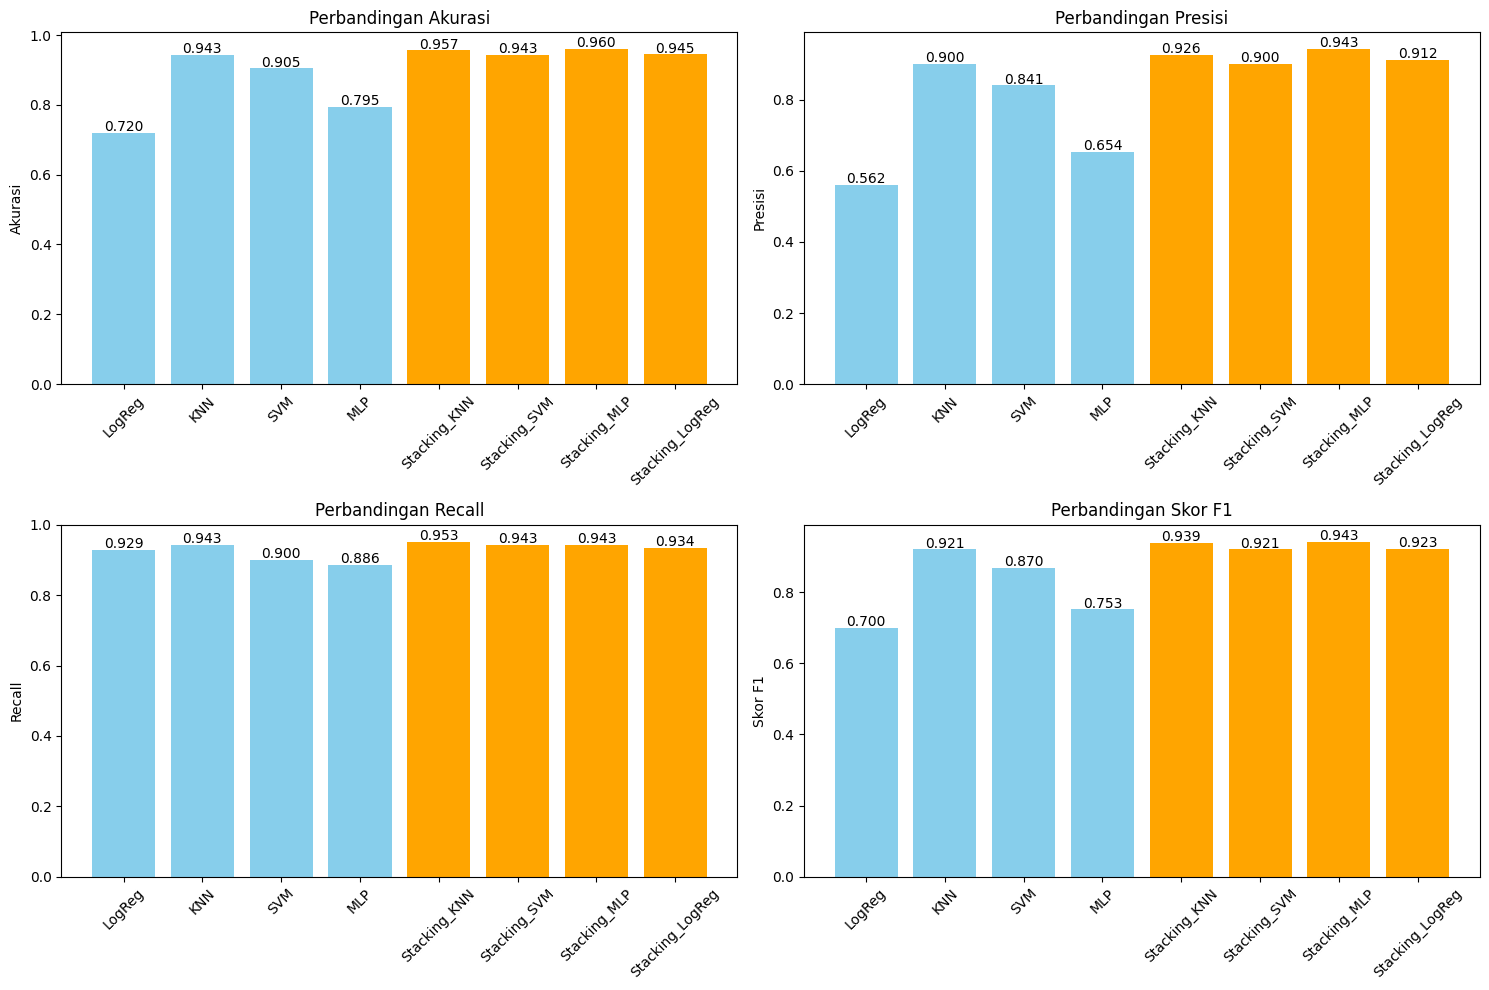

In [125]:
# Visualisasi perbandingan
plt.figure(figsize=(15, 10))

# perbandingan akurasi
plt.subplot(2, 2, 1)
models = df_perbandingan['Model']
accuracy = df_perbandingan['Akurasi']
colors = ['skyblue']*4 + ['orange']*5  # Blue for base, orange for stacking
plt.bar(models, accuracy, color=colors)
plt.title('Perbandingan Akurasi')
plt.ylabel('Akurasi')
plt.xticks(rotation=45)
for i, v in enumerate(accuracy):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

# perbandingan presisi
plt.subplot(2, 2, 2)
precision = df_perbandingan['Presisi']
plt.bar(models, precision, color=colors)
plt.title('Perbandingan Presisi')
plt.ylabel('Presisi')
plt.xticks(rotation=45)
for i, v in enumerate(precision):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

# perbandingan recall
plt.subplot(2, 2, 3)
recall = df_perbandingan['Recall']
plt.bar(models, recall, color=colors)
plt.title('Perbandingan Recall')
plt.ylabel('Recall')
plt.xticks(rotation=45)
for i, v in enumerate(recall):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

# perbandingan skor F1
plt.subplot(2, 2, 4)
f1_scores = df_perbandingan['Skor-F1']
plt.bar(models, f1_scores, color=colors)
plt.title('Perbandingan Skor F1')
plt.ylabel('Skor F1')
plt.xticks(rotation=45)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

# CONFUNTION MATRIX

Confusion Matrix untuk Model Dasar:

LogReg (Base Model):


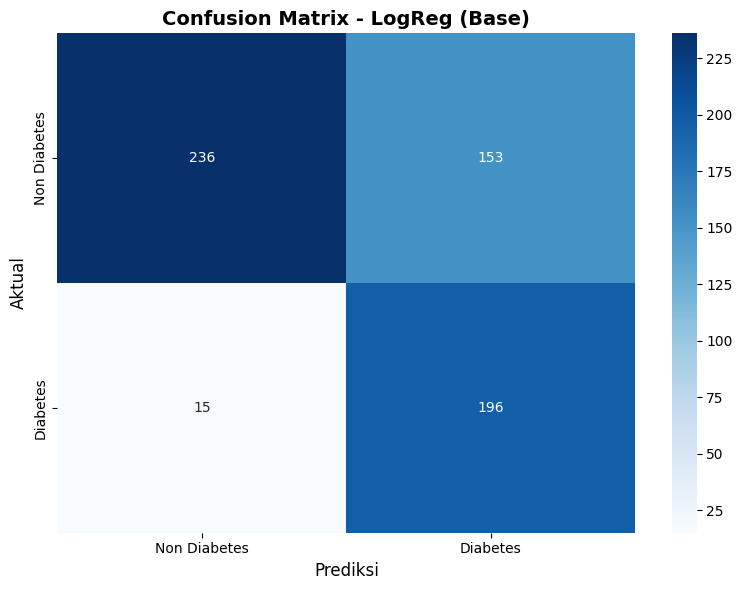


KNN (Base Model):


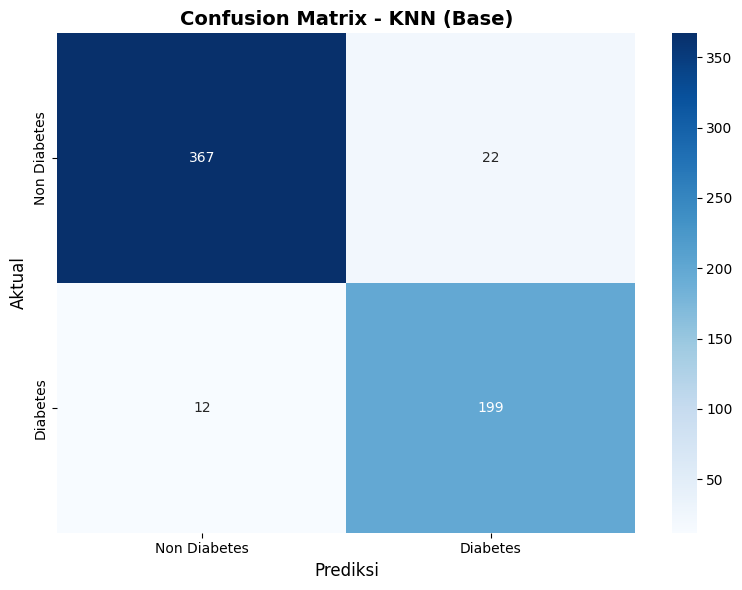


SVM (Base Model):


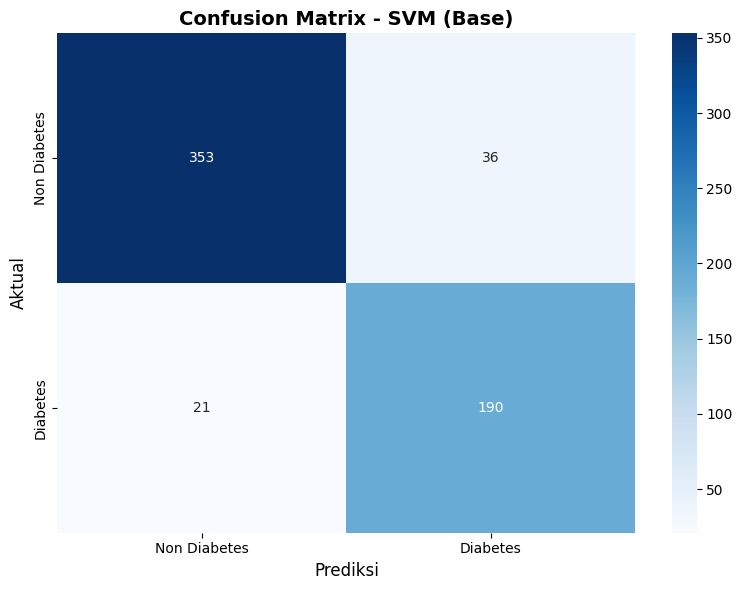


MLP (Base Model):


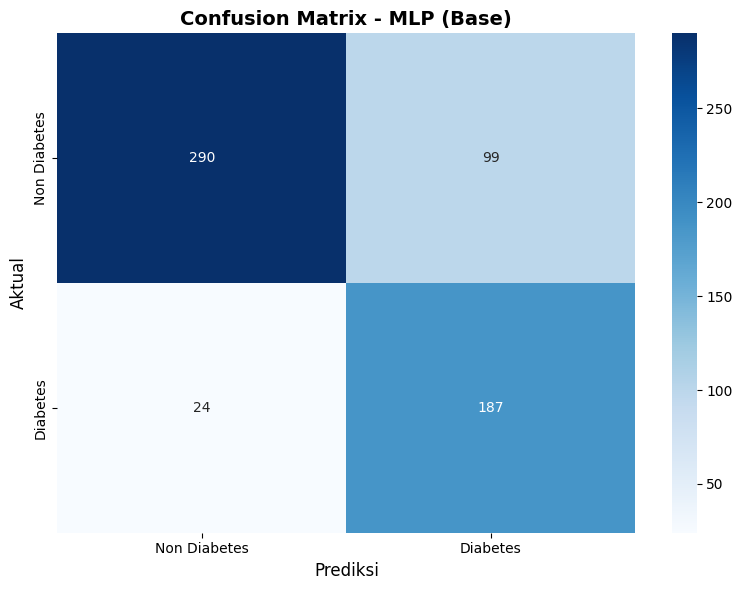



Confusion Matrix untuk Model Stacking:

Stacking_KNN:


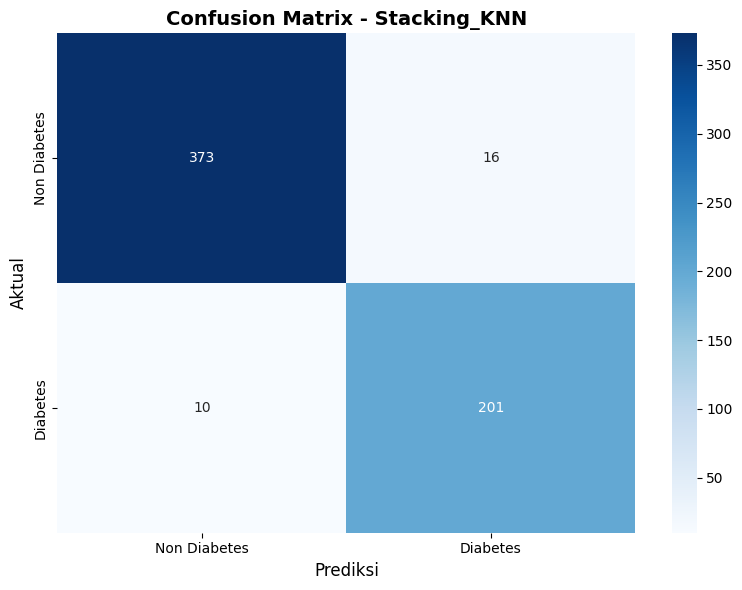


Stacking_SVM:


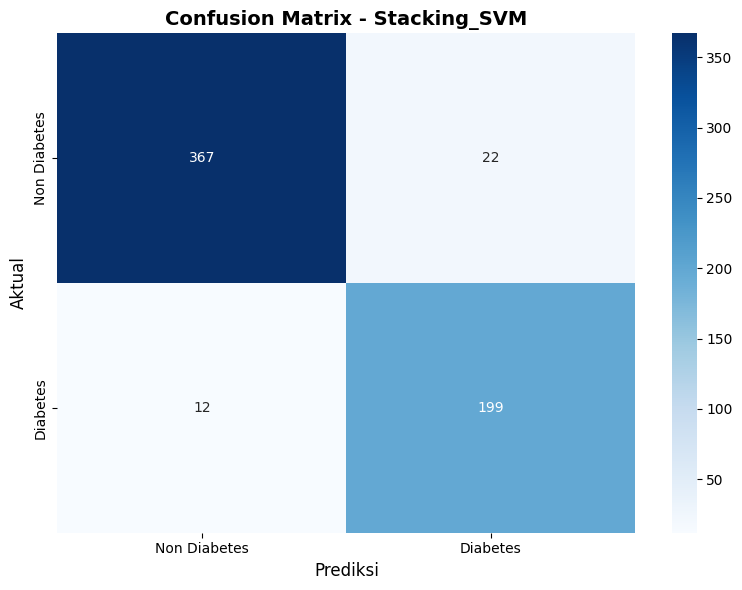


Stacking_MLP:


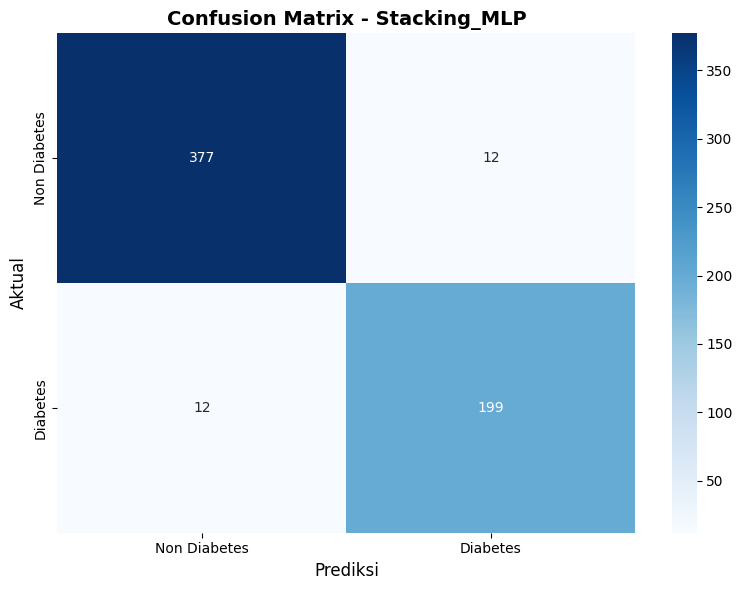


Stacking_LogReg:


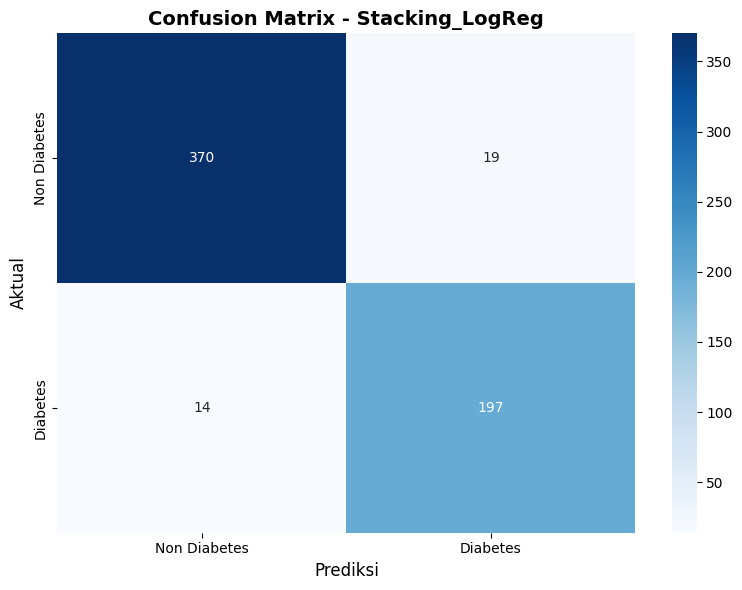

In [126]:
# Fungsi untuk plot confusion matrix
def plot_confusion_matrix(y_asli, y_prediksi, nama_model):
    # Buat figure dan axes baru untuk setiap plot
    fig, ax = plt.subplots(figsize=(8, 6))

    cm = confusion_matrix(y_asli, y_prediksi)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non Diabetes', 'Diabetes'],
                yticklabels=['Non Diabetes', 'Diabetes'])
    ax.set_title(f'Confusion Matrix - {nama_model}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=12)
    ax.set_ylabel('Aktual', fontsize=12)


    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("Confusion Matrix untuk Model Dasar:")

# Plot confusion matrix untuk model dasar
for nama_model, prediksi in pred_model_dasar.items():
    print(f"\n{nama_model} (Base Model):")
    plot_confusion_matrix(y_uji, prediksi, f'{nama_model} (Base)')

print("\n\nConfusion Matrix untuk Model Stacking:")

# Plot confusion matrix untuk model stacking
for nama_model, prediksi in stacking_predictions.items():
    print(f"\n{nama_model}:")
    plot_confusion_matrix(y_uji, prediksi, nama_model)


# SIMPAN MODEL 

In [127]:
os.makedirs("model_deployment", exist_ok=True)
# untuk prepocessing
joblib.dump(skala, "model_deployment/minmax_scaler.pkl")
joblib.dump(imputer_knn, "model_deployment/knn_imputer.pkl")

# untuk base model
joblib.dump(lr_final, "model_deployment/logistic_regression.pkl")
joblib.dump(knn_final, "model_deployment/knn.pkl")
joblib.dump(svm_final, "model_deployment/svm.pkl")
joblib.dump(mlp_final, "model_deployment/mlp.pkl")

# untuk meta learner
joblib.dump(knn_meta_final, "model_deployment/knn_meta.pkl")
joblib.dump(svm_meta_final, "model_deployment/svm_meta.pkl")
joblib.dump(mlp_meta_final, "model_deployment/mlp_meta.pkl")
joblib.dump(logreg_meta_final, "model_deployment/logreg_meta.pkl")

# info tambahan
model_info = {
    'kolom_imputasi': kolom_imputasi,
    'fitur': X.columns.tolist(),
    'best_model' : 'Stacking_MLP',
}

joblib.dump(model_info, "model_deployment/model_info.pkl")

['model_deployment/model_info.pkl']

# TEST PREDIKSI

In [128]:
# Load model untuk prediksi
def load_models():
    imputer = joblib.load('model_deployment/knn_imputer.pkl')
    scaler = joblib.load('model_deployment/minmax_scaler.pkl')

    # Load base models
    lr_model = joblib.load('model_deployment/logistic_regression.pkl')
    knn_model = joblib.load('model_deployment/knn.pkl')
    svm_model = joblib.load('model_deployment/svm.pkl')
    mlp_model = joblib.load('model_deployment/mlp.pkl')

    # Load meta learner
    meta_model = joblib.load('model_deployment/mlp_meta.pkl')

    # Load info
    info = joblib.load('model_deployment/model_info.pkl')

    return imputer, scaler, lr_model, knn_model, svm_model, mlp_model, meta_model, info

def predict_diabetes(data_input):
    # Load semua model
    imputer, scaler, lr_model, knn_model, svm_model, mlp_model, meta_model, info = load_models()

    # Preprocessing
    df = pd.DataFrame([data_input])

    # Imputasi
    for col in info['kolom_imputasi']:
        if df[col].iloc[0] == 0:
            df[col] = np.nan

    df_imputed = pd.DataFrame(imputer.transform(df), columns=info['fitur'])
    df_scaled = pd.DataFrame(scaler.transform(df_imputed), columns=info['fitur'])

    # Prediksi base models
    lr_prob = lr_model.predict_proba(df_scaled)
    knn_prob = knn_model.predict_proba(df_scaled)
    svm_prob = svm_model.predict_proba(df_scaled)
    mlp_prob = mlp_model.predict_proba(df_scaled)

    # Gabungkan untuk meta features
    meta_features = np.column_stack([lr_prob, knn_prob, svm_prob, mlp_prob])

    # Prediksi final
    result = meta_model.predict(meta_features)[0]
    prob = meta_model.predict_proba(meta_features)[0]

    return {
        'prediksi': 'Diabetes' if result == 1 else 'Non Diabetes',
    }

In [129]:
# Test dengan beberapa data
test_data = [
    {
        'Pregnancies': 2,
        'Glucose': 85,
        'BloodPressure': 66,
        'SkinThickness': 29,
        'Insulin': 0,
        'BMI': 26.6,
        'DiabetesPedigreeFunction': 0.351,
        'Age': 31
    },
    {
        'Pregnancies': 8,
        'Glucose': 183,
        'BloodPressure': 64,
        'SkinThickness': 0,
        'Insulin': 0,
        'BMI': 23.3,
        'DiabetesPedigreeFunction': 0.672,
        'Age': 32
    },
    {
        'Pregnancies': 0,
        'Glucose': 137,
        'BloodPressure': 40,
        'SkinThickness': 35,
        'Insulin': 168,
        'BMI': 43.1,
        'DiabetesPedigreeFunction': 2.288,
        'Age': 33
    }
]

print("Testing dengan sample data:")
for i, data in enumerate(test_data, 1):
    hasil = predict_diabetes(data)
    print(f"Data {i}:")
    print(f"  Input: {data}")
    print(f"  Prediksi: {hasil['prediksi']}")
    print()

Testing dengan sample data:
Data 1:
  Input: {'Pregnancies': 2, 'Glucose': 85, 'BloodPressure': 66, 'SkinThickness': 29, 'Insulin': 0, 'BMI': 26.6, 'DiabetesPedigreeFunction': 0.351, 'Age': 31}
  Prediksi: Non Diabetes

Data 2:
  Input: {'Pregnancies': 8, 'Glucose': 183, 'BloodPressure': 64, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 23.3, 'DiabetesPedigreeFunction': 0.672, 'Age': 32}
  Prediksi: Diabetes

Data 3:
  Input: {'Pregnancies': 0, 'Glucose': 137, 'BloodPressure': 40, 'SkinThickness': 35, 'Insulin': 168, 'BMI': 43.1, 'DiabetesPedigreeFunction': 2.288, 'Age': 33}
  Prediksi: Diabetes



In [130]:
os.makedirs("data_deployment", exist_ok=True)

In [131]:
# 1. Data Training (setelah SMOTE)
X_train_final = pd.DataFrame(X_latih_smote, columns=X.columns)
X_train_final['Outcome'] = y_latih_smote
# Simpan data training
X_train_final.to_csv("data_deployment/data_training_smote.csv", index=False)
print(f"Data training (setelah SMOTE) disimpan: {X_train_final.shape}")


# 2. Data Testing (dinormalisasi)
X_test_final = pd.DataFrame(X_uji_dinormalisasi, columns=X.columns)
X_test_final['Outcome'] = y_uji
# Simpan data testing
X_test_final.to_csv("data_deployment/data_testing_normalized.csv", index=False)
print(f"Data testing (dinormalisasi) disimpan: {X_test_final.shape}")

Data training (setelah SMOTE) disimpan: (1854, 9)
Data testing (dinormalisasi) disimpan: (600, 9)


In [132]:
# 3. Data Training Meta (meta features untuk training meta learner)
X_meta_train_final = pd.DataFrame(X_meta_latih, columns=[
    'lr_prob_0', 'lr_prob_1',      # LR probabilitas kelas 0 dan 1
    'knn_prob_0', 'knn_prob_1',    # KNN probabilitas kelas 0 dan 1
    'svm_prob_0', 'svm_prob_1',    # SVM probabilitas kelas 0 dan 1
    'mlp_prob_0', 'mlp_prob_1'     # MLP probabilitas kelas 0 dan 1
])
X_meta_train_final['Outcome'] = y_meta_latih
# Simpan data meta training
X_meta_train_final.to_csv("data_deployment/data_meta_training.csv", index=False)
print(f"Data meta training disimpan: {X_meta_train_final.shape}")

# 4. Data Testing Meta (meta features untuk testing meta learner)
X_meta_test_final = pd.DataFrame(X_meta_uji, columns=[
    'lr_prob_0', 'lr_prob_1',      # LR probabilitas kelas 0 dan 1
    'knn_prob_0', 'knn_prob_1',    # KNN probabilitas kelas 0 dan 1
    'svm_prob_0', 'svm_prob_1',    # SVM probabilitas kelas 0 dan 1
    'mlp_prob_0', 'mlp_prob_1'     # MLP probabilitas kelas 0 dan 1
])
X_meta_test_final['Outcome'] = y_meta_uji
# Simpan data meta testing
X_meta_test_final.to_csv("data_deployment/data_meta_testing.csv", index=False)
print(f"Data meta testing disimpan: {X_meta_test_final.shape}")


Data meta training disimpan: (1854, 9)
Data meta testing disimpan: (600, 9)


In [133]:
import numpy as np
import sklearn
import joblib
import pandas as pd

print(f"Numpy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Joblib: {joblib.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")


Numpy: 2.3.5
Scikit-learn: 1.7.2
Joblib: 1.5.2
Pandas: 2.3.3
matplotlib: 3.10.7
